# TextAnalysis
Entrada: `acciones_preparadas.csv` (8 partidos, una fila cada uno). Calcula un embedding por partido, similitud entre todos (H1) y proyección sobre un eje A–H (H2).

## TEXT-01: leer el corpus

In [1]:
import pandas as pd

corpus = pd.read_csv('acciones_preparadas.csv')
assert len(corpus) == 8 and corpus['id_partido'].is_unique
corpus[['id_partido', 'partido', 'num_propuestas']]

,id_partido,partido,num_propuestas
0,A,Renovación Popular Social,5
1,B,Frente Progresista,7
2,C,Movimiento Democrático,4
3,D,Centro Cívico,6
4,E,Alianza Nacional,8
5,F,Libertad Republicana,5
6,G,Futuro Liberal,9
7,H,Mercado y Libertad,6


## TEXT-02: modelo de embeddings
SBERT multilingüe preentrenado, sin ajustar. El límite de tokens sale del propio modelo.

In [2]:
from sentence_transformers import SentenceTransformer
import nltk
nltk.download('punkt_tab', quiet=True)

embedding_model = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")
LIMITE = embedding_model.max_seq_length

def contar_tokens(texto):
    return len(embedding_model.tokenizer.encode(texto, add_special_tokens=True))

print('Límite de tokens del modelo:', LIMITE)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.12k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Límite de tokens del modelo: 128


## TEXT-03: fragmentar y verificar
Las propuestas ya son cortas; se comprueba el límite en vez de asumirlo. Se verifica que fragmentar no pierda texto.

In [3]:
from nltk.tokenize import sent_tokenize

def dividir_por_palabras(oracion, limite=LIMITE):
    palabras = oracion.split()
    fragmentos, actual = [], []
    for palabra in palabras:
        candidato = ' '.join(actual + [palabra])
        if contar_tokens(candidato) > limite and actual:
            fragmentos.append(' '.join(actual))
            actual = [palabra]
        else:
            actual.append(palabra)
    if actual:
        fragmentos.append(' '.join(actual))
    return fragmentos

def fragmentar(texto, id_partido, limite=LIMITE):
    oraciones = sent_tokenize(texto, language='spanish')
    fragmentos = []
    for oracion in oraciones:
        if contar_tokens(oracion) <= limite:
            fragmentos.append(oracion)
        else:
            fragmentos.extend(dividir_por_palabras(oracion, limite))
    reconstruido = ''.join(fragmentos).replace(' ', '')
    original = texto.replace(' ', '')
    assert reconstruido == original, f'{id_partido}: la fragmentación no preserva el texto.'
    return fragmentos

for _, fila in corpus.iterrows():
    frags = fragmentar(fila['texto'], fila['id_partido'])
    ok = 'OK' if len(frags) == fila['num_propuestas'] else 'REVISAR'
    print(fila['id_partido'], '->', len(frags), 'fragmentos', f"(num_propuestas={fila['num_propuestas']})", ok)

A -> 5 fragmentos (num_propuestas=5) OK
B -> 7 fragmentos (num_propuestas=7) OK
C -> 4 fragmentos (num_propuestas=4) OK
D -> 6 fragmentos (num_propuestas=6) OK
E -> 8 fragmentos (num_propuestas=8) OK
F -> 5 fragmentos (num_propuestas=5) OK
G -> 9 fragmentos (num_propuestas=9) OK
H -> 6 fragmentos (num_propuestas=6) OK


## TEXT-04: un embedding por partido
Promedio normalizado de los embeddings de sus propuestas. Cada propuesta pesa igual — por eso `num_propuestas` queda registrado.

In [4]:
import numpy as np

def embedding_partido(texto, id_partido):
    fragmentos = fragmentar(texto, id_partido)
    vectores = embedding_model.encode(fragmentos, normalize_embeddings=True)
    promedio = vectores.mean(axis=0)
    return promedio / np.linalg.norm(promedio)

corpus['embedding'] = [embedding_partido(t, i) for t, i in zip(corpus['texto'], corpus['id_partido'])]
E = np.stack(corpus['embedding'].values)
print('Matriz de embeddings:', E.shape)

Matriz de embeddings: (8, 768)


## TEXT-05: H1 — similitud coseno

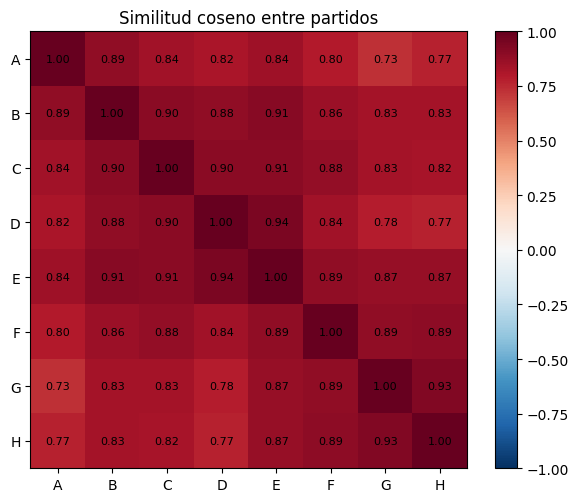

In [5]:
import matplotlib.pyplot as plt

ids = corpus['id_partido'].tolist()
S = E @ E.T

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(S, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(8)); ax.set_xticklabels(ids)
ax.set_yticks(range(8)); ax.set_yticklabels(ids)
for i in range(8):
    for j in range(8):
        ax.text(j, i, f'{S[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im); plt.title('Similitud coseno entre partidos'); plt.tight_layout()
import os
os.makedirs('resultados', exist_ok=True)
plt.savefig('resultados/similitud.png', dpi=200, bbox_inches='tight')
plt.show()

Sin whitening: con 8 documentos la covarianza tiene rango ≤7, insuficiente para un espacio de cientos de dimensiones. Se reporta el coseno crudo, sin umbral universal.

## TEXT-06: pares más y menos similares
Revisar `num_propuestas` antes de interpretar: un partido con más propuestas puede parecer más 'genérico', no necesariamente más moderado.

In [6]:
import itertools

pares = [(ids[i], ids[j], S[i,j], corpus['num_propuestas'][i], corpus['num_propuestas'][j])
          for i, j in itertools.combinations(range(8), 2)]
pares.sort(key=lambda x: -x[2])

print('Más similares:')
for p in pares[:3]:
    print(f'  {p[0]}({p[3]}) - {p[1]}({p[4]}): {p[2]:.3f}')
print('Menos similares:')
for p in pares[-3:]:
    print(f'  {p[0]}({p[3]}) - {p[1]}({p[4]}): {p[2]:.3f}')

Más similares:
  D(6) - E(8): 0.938
  G(9) - H(6): 0.927
  B(7) - E(8): 0.909
Menos similares:
  A(5) - H(6): 0.772
  D(6) - H(6): 0.766
  A(5) - G(9): 0.729


## TEXT-07: H2 — eje A–H
A y H son anclas por decisión del investigador, no por el modelo. Eje de A (-1) a H (+1).

In [7]:
a = E[ids.index('A')]
h = E[ids.index('H')]
v = h - a
m = (a + h) / 2

s = 2 * (E - m) @ v / (v @ v)
corpus['posicion_eje'] = s
corpus[['id_partido', 'partido', 'posicion_eje', 'num_propuestas']].sort_values('posicion_eje')

,id_partido,partido,posicion_eje,num_propuestas
0,A,Renovación Popular Social,-1.000000,5
1,B,Frente Progresista,-0.231627,7
3,D,Centro Cívico,-0.231454,6
2,C,Movimiento Democrático,-0.071512,4
4,E,Alianza Nacional,0.100830,8
5,F,Libertad Republicana,0.433779,5
6,G,Futuro Liberal,0.866436,9
7,H,Mercado y Libertad,1.000000,6


## TEXT-08: distancia al eje
Cuánto del contenido de cada partido no se explica por la dimensión estatal-mercado:

$$\text{distancia}_i = \left\| (d_i - m) - \frac{s_i}{2}\,v \right\|$$

In [8]:
def distancia_al_eje(d, m, v, s_i):
    proyeccion = (s_i / 2) * v
    return np.linalg.norm((d - m) - proyeccion)

corpus['distancia_eje'] = [distancia_al_eje(E[i], m, v, s[i]) for i in range(8)]
corpus[['id_partido', 'posicion_eje', 'distancia_eje']].sort_values('posicion_eje')

,id_partido,posicion_eje,distancia_eje
0,A,-1.000000,2.776463e-08
1,B,-0.231627,3.982481e-01
3,D,-0.231454,5.435314e-01
2,C,-0.071512,4.703225e-01
4,E,0.100830,4.159429e-01
5,F,0.433779,4.170182e-01
6,G,0.866436,3.801923e-01
7,H,1.000000,2.823192e-08


## TEXT-09: visualizar H2
Que A y H queden en -1 y +1 es diseño, no evidencia. La evidencia es la dispersión de B-G.

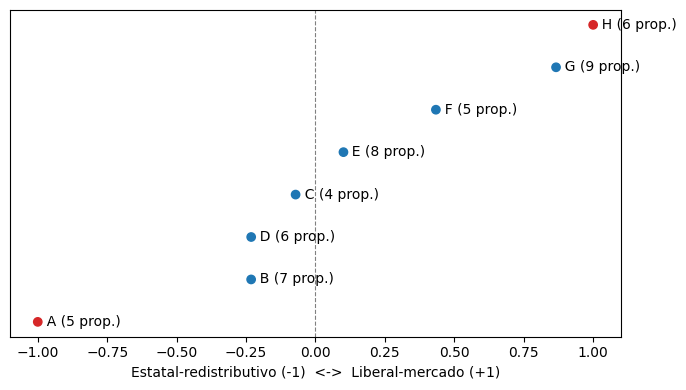

Rango de B-G en el eje: 1.098


In [9]:
fig, ax = plt.subplots(figsize=(7,4))
orden = corpus.sort_values('posicion_eje')
colores = ['tab:red' if p in ('A','H') else 'tab:blue' for p in orden['id_partido']]
ax.scatter(orden['posicion_eje'], range(8), c=colores)
for y, (_, fila) in enumerate(orden.iterrows()):
    ax.text(fila['posicion_eje'], y, f"  {fila['id_partido']} ({fila['num_propuestas']} prop.)", va='center')
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_yticks([]); ax.set_xlabel('Estatal-redistributivo (-1)  <->  Liberal-mercado (+1)')
plt.tight_layout()
import os
os.makedirs('resultados', exist_ok=True)
plt.savefig('resultados/scores.png', dpi=200, bbox_inches='tight')
plt.show()

disp = corpus.loc[~corpus['id_partido'].isin(['A','H']), 'posicion_eje']
print('Rango de B-G en el eje:', round(disp.max() - disp.min(), 3))

## Qué no responde este análisis
El eje resume solo "Economía y papel del Estado", no toda la ideología. La similitud entre propuestas no explica la causa de la coincidencia (puede ser convergencia genuina o lenguaje estándar del género). `num_propuestas` fue decisión de cada partido, no un dato neutral: afecta el promedio de H1 y debe leerse junto a los resultados.